# BASELINE - GRAPHSAGE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import random

In [4]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [5]:
checkpoint = torch.load(f"{DATA_DIR}/processed/filtered_graph.pt", weights_only=False)
data = checkpoint["data"]

with open(f"{DATA_DIR}/processed/edge_splits/train_pos.pkl", "rb") as f:
    train_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/edge_splits/val_pos.pkl", "rb") as f:
    val_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/train_neg.pkl", "rb") as f:
    train_neg = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/val_neg.pkl", "rb") as f:
    val_neg = pickle.load(f)

In [6]:
from torch_geometric.nn import HeteroConv, SAGEConv
from torch_geometric.transforms import ToUndirected
from sklearn.metrics import roc_auc_score, average_precision_score

In [7]:
data=ToUndirected()(data)
print(data)

HeteroData(
  Compound={ num_nodes=1441 },
  Disease={ num_nodes=134 },
  Gene={ num_nodes=18270 },
  (Compound, CtD, Disease)={ edge_index=[2, 487] },
  (Gene, GiG, Gene)={ edge_index=[2, 294328] },
  (Disease, DdG, Gene)={ edge_index=[2, 7623] },
  (Compound, CbG, Gene)={ edge_index=[2, 11571] },
  (Compound, CuG, Gene)={ edge_index=[2, 18756] },
  (Disease, DaG, Gene)={ edge_index=[2, 12623] },
  (Gene, GcG, Gene)={ edge_index=[2, 123380] },
  (Gene, Gr>G, Gene)={ edge_index=[2, 527966] },
  (Compound, CdG, Gene)={ edge_index=[2, 21102] },
  (Disease, DuG, Gene)={ edge_index=[2, 7731] },
  (Disease, rev_CtD, Compound)={ edge_index=[2, 487] },
  (Gene, rev_DdG, Disease)={ edge_index=[2, 7623] },
  (Gene, rev_CbG, Compound)={ edge_index=[2, 11571] },
  (Gene, rev_CuG, Compound)={ edge_index=[2, 18756] },
  (Gene, rev_DaG, Disease)={ edge_index=[2, 12623] },
  (Gene, rev_CdG, Compound)={ edge_index=[2, 21102] },
  (Gene, rev_DuG, Disease)={ edge_index=[2, 7731] }
)


In [8]:
EMB_DIM=32

for node_type in data.node_types:
    num_nodes=data[node_type].num_nodes
    data[node_type].x=nn.Parameter(torch.randn(num_nodes, EMB_DIM))

In [9]:
import torch
from copy import deepcopy # deepcopy is not strictly needed after change, but kept for minimal change

# Clone full graph
train_data = data.clone()

# Original CtD edges
edge_index = train_data[('Compound', 'CtD', 'Disease')].edge_index

# Define device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Convert train_pos to tensor
train_pos_tensor = torch.tensor(train_pos, dtype=torch.long, device=device).t()

# Keep only training edges
train_data[('Compound', 'CtD', 'Disease')].edge_index = train_pos_tensor

print("Original CtD edges:", edge_index.shape[1])
print("Training CtD edges:", train_pos_tensor.shape[1])

Original CtD edges: 487
Training CtD edges: 340


In [10]:
from torch_geometric.transforms import ToUndirected

train_data = ToUndirected()(train_data)
train_data = train_data.to(device)

In [11]:
class HeteroGraphSAGE(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.conv1=HeteroConv(
            {
                edge_type: SAGEConv((-1, -1), hidden_dim)
                for edge_type in data.edge_types
            },
            aggr="sum"
        )

        self.conv2=HeteroConv(
            {
                edge_type: SAGEConv((-1, -1), hidden_dim)
                for edge_type in data.edge_types
            },
            aggr="sum"
        )

    def forward(self, x_dict, edge_index_dict):
        x_dict=self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.dropout(v, p=0.3, training=self.training)
          for k, v in x_dict.items()}
        x_dict=self.conv2(x_dict, edge_index_dict)
        return x_dict

In [12]:
def dot_decoder(z_drug, z_disease, edges):
    device=z_drug.device

    drug_idx=torch.tensor(
        [e[0] for e in edges],
        device=device
    )
    disease_idx=torch.tensor(
        [e[1] for e in edges],
        device=device
    )

    scores=(z_drug[drug_idx] * z_disease[disease_idx]).sum(dim=1)
    return scores

In [13]:
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'Tesla T4')

In [14]:
train_losses=[]
val_aucs=[]
val_aps=[]

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

model = HeteroGraphSAGE(EMB_DIM).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

using device: cuda


In [16]:
def train_step(pos_edges, neg_edges):
    model.train()
    optimizer.zero_grad()

    z=model(train_data.x_dict, train_data.edge_index_dict)

    pos_scores=dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores=dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores=torch.cat([pos_scores, neg_scores])
    labels=torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ]).to(device)

    loss=F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(pos_edges, neg_edges):
    model.eval()

    z=model(train_data.x_dict, train_data.edge_index_dict)

    pos_scores=dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores=dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores=torch.cat([pos_scores, neg_scores]).cpu()
    labels=torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ])

    auc=roc_auc_score(labels, scores)
    ap=average_precision_score(labels, scores)

    return auc, ap

In [18]:
best_val_ap=0.0
patience=10
patience_counter=0
NUM_EPOCHS=100

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_step(train_pos, train_neg)
    val_auc, val_ap = evaluate(val_pos, val_neg)

    print(f"Epoch {epoch:03d} | " f"Loss: {loss:.4f} | " f"Val AUC: {val_auc:.4f} | " f"Val AP: {val_ap:.4f}")

    train_losses.append(loss)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)


    if val_ap > best_val_ap:
        best_val_ap = val_ap
        patience_counter = 0
        torch.save(model.state_dict(), "graphsage_baseline.pt")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("early stopping triggered")
        break

Epoch 001 | Loss: 7.3845 | Val AUC: 0.5498 | Val AP: 0.5624
Epoch 002 | Loss: 4.2418 | Val AUC: 0.6399 | Val AP: 0.6229
Epoch 003 | Loss: 2.7205 | Val AUC: 0.7118 | Val AP: 0.6950
Epoch 004 | Loss: 2.0055 | Val AUC: 0.7598 | Val AP: 0.7422
Epoch 005 | Loss: 1.2761 | Val AUC: 0.7857 | Val AP: 0.7803
Epoch 006 | Loss: 1.2088 | Val AUC: 0.7881 | Val AP: 0.7910
Epoch 007 | Loss: 0.7504 | Val AUC: 0.7853 | Val AP: 0.7966
Epoch 008 | Loss: 0.7695 | Val AUC: 0.7906 | Val AP: 0.8080
Epoch 009 | Loss: 0.5675 | Val AUC: 0.8020 | Val AP: 0.8252
Epoch 010 | Loss: 0.5672 | Val AUC: 0.8045 | Val AP: 0.8292
Epoch 011 | Loss: 0.2836 | Val AUC: 0.8071 | Val AP: 0.8363
Epoch 012 | Loss: 0.3623 | Val AUC: 0.8060 | Val AP: 0.8390
Epoch 013 | Loss: 0.2664 | Val AUC: 0.8054 | Val AP: 0.8384
Epoch 014 | Loss: 0.3226 | Val AUC: 0.8045 | Val AP: 0.8363
Epoch 015 | Loss: 0.2902 | Val AUC: 0.8052 | Val AP: 0.8380
Epoch 016 | Loss: 0.2047 | Val AUC: 0.8112 | Val AP: 0.8446
Epoch 017 | Loss: 0.2353 | Val AUC: 0.81

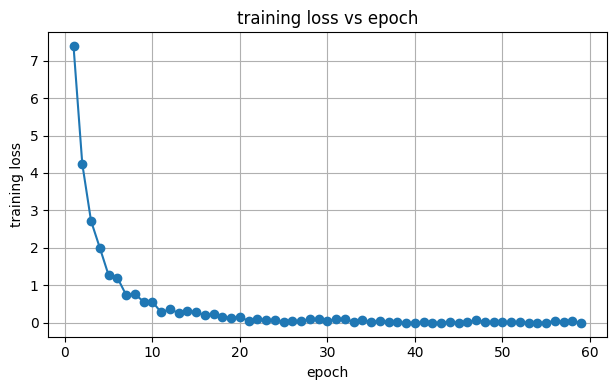

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("training loss vs epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

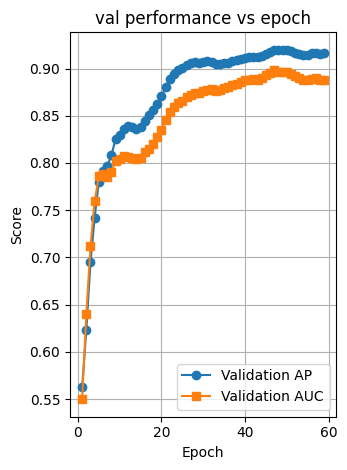

In [20]:
plt.subplot(1, 2, 2)
plt.plot(epochs, val_aps, label="Validation AP", marker="o")
plt.plot(epochs, val_aucs, label="Validation AUC", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("val performance vs epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
import torch
import pickle

@torch.no_grad()
def extract_embeddings(model, data):
    model.eval()
    z = model(data.x_dict, data.edge_index_dict)
    return {
        "Compound": z["Compound"].cpu(),
        "Disease": z["Disease"].cpu(),
        "Gene": z["Gene"].cpu()
    }

embeddings = extract_embeddings(model, train_data)

baseline_artifact = {
    "model_name": "HeteroGraphSAGE_baseline",
    "embedding_dim": 32,
    "dropout": 0.3,
    "negative_sampling_ratio": "1:1",
    "num_epochs": len(train_losses),
    "best_val_auc": max(val_aucs),
    "best_val_ap": max(val_aps),
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "val_aps": val_aps,
    "embeddings": embeddings
}

torch.save(
    baseline_artifact,
    "graphsage_baseline.pt"
)

print("Baseline artifact saved to graphsage_baseline_artifact.pt")

Baseline artifact saved to graphsage_baseline_artifact.pt


In [22]:
SAVE_PATH = "/content/drive/MyDrive/drug_repurposing/models/"
torch.save(baseline_artifact, SAVE_PATH + "graphsage_baseline_artifact.pt")

In [23]:
import torch

artifact = torch.load("/content/drive/MyDrive/drug_repurposing/models/graphsage_baseline_artifact.pt", weights_only=False)

embeddings = artifact["embeddings"]

z_drug = embeddings["Compound"]
z_disease = embeddings["Disease"]
z_gene = embeddings["Gene"]

print(z_drug.shape, z_disease.shape, z_gene.shape)

torch.Size([1441, 32]) torch.Size([134, 32]) torch.Size([18270, 32])


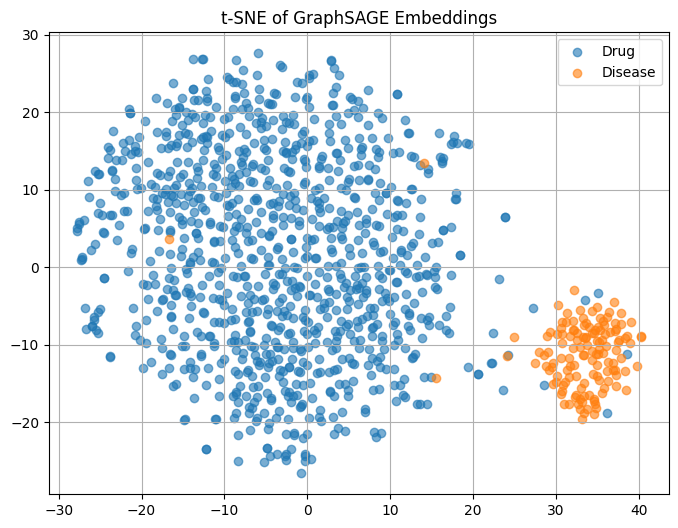

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# sample for speed
num_samples = 1000

drug_sample = z_drug[torch.randperm(z_drug.size(0))[:num_samples]]
disease_sample = z_disease[torch.randperm(z_disease.size(0))[:num_samples]]

X = torch.cat([drug_sample, disease_sample], dim=0).numpy()

labels = np.array(
    ["Drug"] * len(drug_sample) + ["Disease"] * len(disease_sample)
)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_emb = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["Drug", "Disease"]:
    idx = labels == label
    plt.scatter(X_emb[idx,0], X_emb[idx,1], label=label, alpha=0.6)

plt.legend()
plt.title("t-SNE of GraphSAGE Embeddings")
plt.grid(True)
plt.show()

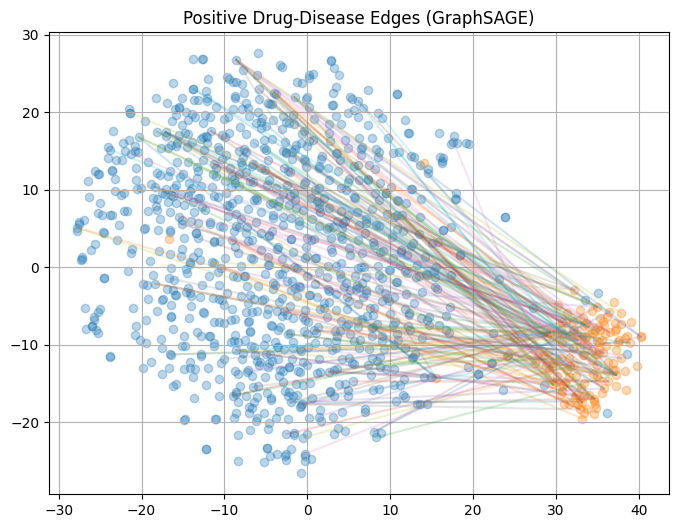

In [25]:
# take subset for clarity
sample_edges = train_pos[:200]

plt.figure(figsize=(8,6))

# plot nodes
plt.scatter(X_emb[:len(drug_sample),0], X_emb[:len(drug_sample),1], alpha=0.3)
plt.scatter(X_emb[len(drug_sample):,0], X_emb[len(drug_sample):,1], alpha=0.3)

# draw edges
for d, dis in sample_edges:
    if d < len(drug_sample) and dis < len(disease_sample):
        plt.plot(
            [X_emb[d,0], X_emb[len(drug_sample)+dis,0]],
            [X_emb[d,1], X_emb[len(drug_sample)+dis,1]],
            alpha=0.2
        )

plt.title("Positive Drug-Disease Edges (GraphSAGE)")
plt.grid(True)
plt.show()

In [27]:
pos_scores=dot_decoder(z_drug, z_disease, val_pos)
neg_scores=dot_decoder(z_drug, z_disease, val_neg)

print("POS STATS")
print("min:", pos_scores.min().item())
print("max:", pos_scores.max().item())
print("mean:", pos_scores.mean().item())

print("\nNEG STATS")
print("min:", neg_scores.min().item())
print("max:", neg_scores.max().item())
print("mean:", neg_scores.mean().item())

print("\nCheck NaNs:")
print("pos NaN:", torch.isnan(pos_scores).any())
print("neg NaN:", torch.isnan(neg_scores).any())

POS STATS
min: -72.98324584960938
max: 109.1893539428711
mean: 33.98945236206055

NEG STATS
min: -74.01551055908203
max: 29.309263229370117
mean: -17.78059959411621

Check NaNs:
pos NaN: tensor(False)
neg NaN: tensor(False)


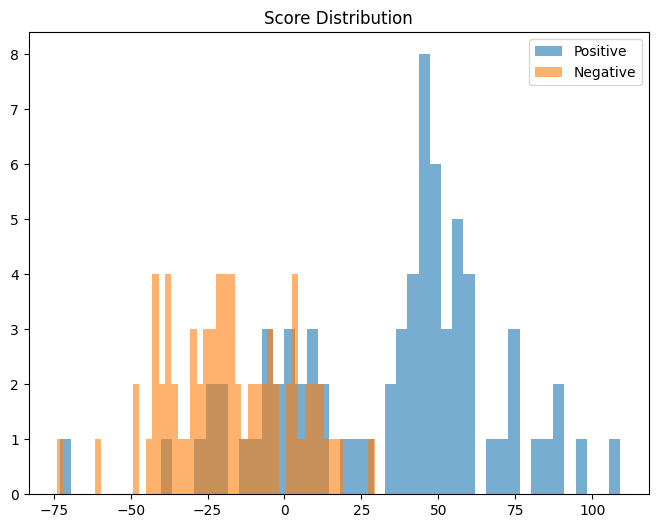

In [29]:
pos = pos_scores.detach().cpu().numpy()
neg = neg_scores.detach().cpu().numpy()

# remove NaNs if any
pos = pos[~np.isnan(pos)]
neg = neg[~np.isnan(neg)]

plt.figure(figsize=(8,6))

plt.hist(pos, bins=50, alpha=0.6, label="Positive")
plt.hist(neg, bins=50, alpha=0.6, label="Negative")

plt.legend()
plt.title("Score Distribution")
plt.show()

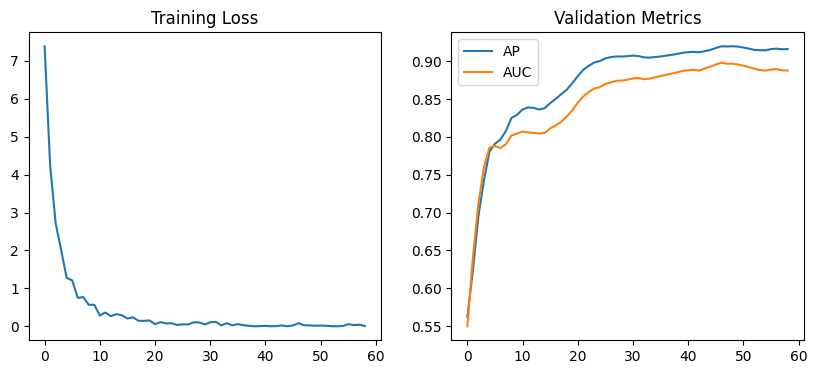

In [30]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(val_aps, label="AP")
plt.plot(val_aucs, label="AUC")
plt.legend()
plt.title("Validation Metrics")

plt.show()